Film surelerinin zamanla azaldigi yonunde bir varsayim var. Netflix'deki iceriklerin, bazi degiskenlerini iceren veri setimize bakacagiz. Gercekten de oyle mi? 

In [12]:
from numpy import float64, short
import pandas as pd
import matplotlib.pyplot as plt

netflix_df_with_duplicates = pd.read_csv('/Users/betulyilmaz/Downloads/netflix_titles.csv')
netflix_df = netflix_df_with_duplicates.drop_duplicates()
print(netflix_df.head())
print(netflix_df.info())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        




Film surelerine bakacagimiz icin type'i sadece 'Movie' olarak filtreledikten sonra isimize yarayabilecek diger degiskenleri aliyoruz.




In [2]:
netflix_movies = netflix_df[netflix_df["type"] == "Movie"]
netflix_movies_col_subset = netflix_movies[["title", "country", "release_year","listed_in", "duration"]]
print(netflix_movies_col_subset.head())

                               title  \
0               Dick Johnson Is Dead   
6   My Little Pony: A New Generation   
7                            Sankofa   
9                       The Starling   
12                      Je Suis Karl   

                                              country  release_year  \
0                                       United States          2020   
6                                                 NaN          2021   
7   United States, Ghana, Burkina Faso, United Kin...          1993   
9                                       United States          2021   
12                            Germany, Czech Republic          2021   

                                           listed_in duration  
0                                      Documentaries   90 min  
6                           Children & Family Movies   91 min  
7   Dramas, Independent Movies, International Movies  125 min  
9                                   Comedies, Dramas  104 min  
12          

'duration' kolonunda 90 min gibi istemedigimiz, bize daha sonra sorun cikaracak 'min' ifadesinden kurtulmamiz lazim.

In [3]:
cols_to_check = ['duration']
for col in cols_to_check:
    netflix_movies_col_subset[col] = netflix_movies_col_subset[col].map(lambda x: str(x).replace('min',''))
print(netflix_movies_col_subset['duration'])

0        90 
6        91 
7       125 
9       104 
12      127 
        ... 
8801     96 
8802    158 
8804     88 
8805     88 
8806    111 
Name: duration, Length: 6131, dtype: object


/var/folders/3c/8rn2jljj21n79jbbg9tbtpjh0000gn/T/ipykernel_6050/272762908.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_movies_col_subset[col] = netflix_movies_col_subset[col].map(lambda x: str(x).replace('min',''))


Yine 'duration' kolonunun tipine baktigimizda object, bunu float'a cevirmemiz lazim.

In [4]:
netflix_movies_col_subset['duration'] = netflix_movies_col_subset['duration'].astype(float)
print(netflix_movies_col_subset.dtypes)

title            object
country          object
release_year      int64
listed_in        object
duration        float64
dtype: object


/var/folders/3c/8rn2jljj21n79jbbg9tbtpjh0000gn/T/ipykernel_6050/4096933493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_movies_col_subset['duration'] = netflix_movies_col_subset['duration'].astype(float)


Artik yillara gore film surelerine bakabiliriz.

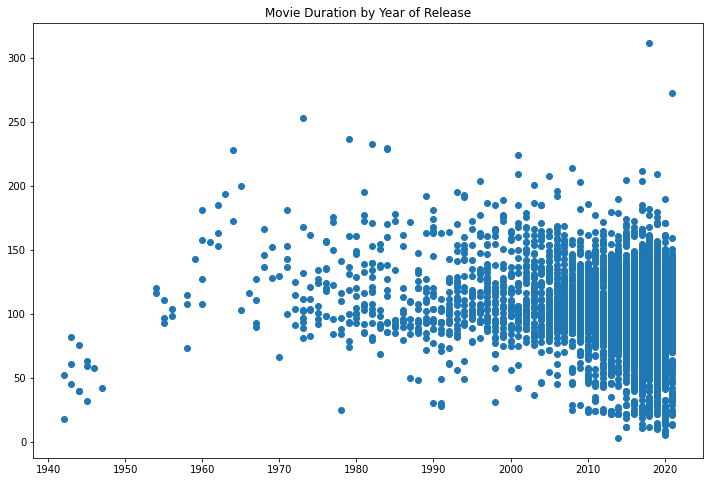

In [5]:
fig = plt.figure(figsize=(12,8))

plt.scatter(netflix_movies_col_subset["release_year"], netflix_movies_col_subset["duration"])
plt.title("Movie Duration by Year of Release")
plt.show()

Bu filmlerden bazilari bir saatten az suruyor. 60 dakikanin altindaki filmler icin DataFrame'imizi filtreleyelim. 
Bu bize ortalamayi neyin asagi cektigine dair bir fikir verebilir.

In [6]:
short_movies = netflix_movies_col_subset[netflix_movies_col_subset['duration'] < 60]
print(short_movies.head())

                                    title               country  release_year  \
45                 My Heroes Were Cowboys                   NaN          2021   
71            A StoryBots Space Adventure                   NaN          2021   
77          Little Singham - Black Shadow                   NaN          2021   
279  Monster Hunter: Legends of the Guild  United States, Japan          2021   
470           Bridgerton - The Afterparty                   NaN          2021   

                                             listed_in  duration  
45                                       Documentaries      23.0  
71                            Children & Family Movies      13.0  
77                  Children & Family Movies, Comedies      48.0  
279  Action & Adventure, Anime Features, Children &...      59.0  
470                                             Movies      39.0  


Kisa filmelerin verimizin uzerinde nasil bir etkiye sahip oldugunu gormek icin onlari kirmizi renk ile gosterelim.

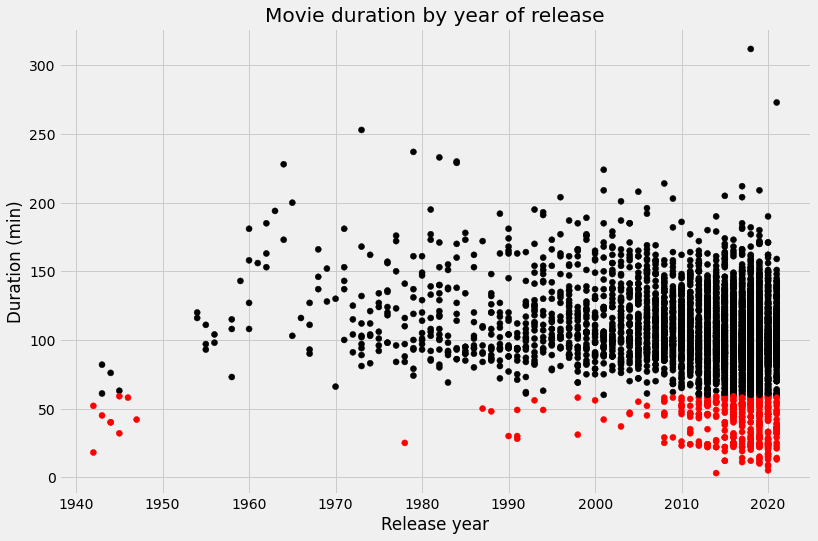

In [10]:
colors = []
for lab, row in netflix_movies_col_subset.iterrows():
    if row['duration'] < 60:
        colors.append("red")
    else:
        colors.append("black")


plt.style.use('fivethirtyeight')
fig = plt.figure(figsize=(12,8))

plt.scatter(netflix_movies_col_subset["release_year"], netflix_movies_col_subset["duration"], c = colors)
plt.title("Movie duration by year of release")
plt.xlabel("Release year")
plt.ylabel("Duration (min)")
plt.show()


Simdilik kesifci veri analizi ile on bir bilgiye sahip olduk. Aslinda film surelerinin kisalamis gibi gorunmesinde onemli bir etken olarak, zaman icinde kisa filmlerin cogalmasi diyebiliriz.